Part 1: Optimal Water Network Design

Short Course SC1: From Best-Guess to Better Decisions: Modern Optimisation for Water Distribution Systems, WDSA/CCWI 2026- Paphos, Cyprus, 18 May 2026

Hands-on tutorial notebook — Part 1 of 3

Authors

* Christos Michalopoulos (christos.michalopoulos@kwrwater.nl) - Part 1
* Lydia Tsiami (lydia.tsiami@kwrwater.nl) - Part 2
* Dennis Zanutto (dennis.zanutto@kwrwater.nl) - Part 3

---
**Overview**

This tutorial explores the single-stage pipe sizing problem, a fundamental challenge in hydraulic engineering.

Designers often struggle with balancing cost, reliability, and hydraulic performance when laying out water infrastructure. In this session, we will demonstrate:

1. **The Challenges**: Identifying the constraints and complexities designers face during the network planning phase.

2. **Advanced Optimization**: Leveraging modern techniques to move beyond manual "best-guess" methods to find mathematically grounded solutions.

3. **Solution Validation**: Evaluating the feasibility and appropriateness of an optimized solution to ensure it meets real-world operational requirements.


## 😴 Imports and other modules

In [ ]:
# @title [RUN] Import modules
!python --version
!pip install condacolab epyt
import condacolab
condacolab.install()

Python 3.11.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.8/79.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [ ]:
# @title [RUN] Import modules
!python --version
!conda install pygmo
from epyt import epanet
import pygmo
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt
from itertools import islice, product
from tqdm import tqdm
import time

# Workshop: Water Network Pipe Sizing Optimisation

> **Goal:** find the least expensive set of pipe diameters that keeps pressure acceptable at every node.

## Learning Objectives
By the end of this workshop you will be able to:
1. Load and simulate a water distribution network in Python using **EPyT**
2. Explain why **brute-force search** is impractical
3. Define a **User-Defined Problem (UDP)** for the PyGMO optimisation framework
4. Handle constraints via a **penalty method** when the algorithm does not support them natively
5. Run a **Optimisation Algorithm** and interpret the results
6. Analyse the **convergence** of an evolutionary algorithm and the sensitivity to penalty weight

## Background: Why Optimise Pipe Diameters?

Water distribution networks consist of hundreds to thousands of pipes. Each pipe must be sized to satisfy two competing goals:

- **Pressure constraint** — every consumer must receive water at >= 30 m head
- **Cost minimisation** — larger pipes cost more (material, installation, maintenance)

The designer's task: find the **smallest pipes that still deliver adequate pressure everywhere**.

This is a classic **combinatorial optimisation problem**: with `n` pipes and `k` diameter choices each, there are `k^n` possible configurations.

### The Two-Loop Benchmark Network

We use the well-known **Two-Loop** test case from the water network optimisation literature:

| Component | Count |
|-----------|------:|
| Reservoir (source) | 1 |
| Junction nodes (consumers) | 6 |
| Pipes (decision variables) | 8 |
| Available diameter choices | 14 |


## Framework Flow
```
   ┌──────────────────────────────────────────┐
   │             PyGMO  (sade)                │ ───▶  optimal solution
   │   algo.evolve(pop) — generates candidates│
   └──────────────────────────────────────────┘
            │  candidate x = [3,5,3,5,...]    ▲  penalised_cost
            │  (8 diameter indices)           │  (one float)
            ▼                                 │
   ┌──────────────────────────────────────────┐
   │         PipeDiamDecider  (UDP)           │
   │  fitness(x) → [cost + c + w x deficit]   │
   └──────────────────────────────────────────┘
            │  x  (same vector)               ▲  (cost, deficit)
            │                                 │
            ▼                                 │
   ┌──────────────────────────────────────────┐
   │         HydraulicPerformances            │
   │  calculateObjectives(x) → (cost, deficit)│
   └──────────────────────────────────────────┘
   ```

## 2. Load and Explore the Network

**EPyT** (EPANET Python Toolkit) wraps the industry-standard EPANET hydraulic solver, developed by the US EPA for water distribution analysis.

The `.inp` file defines the network topology, pipe properties, and demand patterns.

EPANET version 20305 loaded (EPyT version v2.3.5.0 - Last Update: 20/02/2026).
Publication DOI: https://zenodo.org/records/18484878
Input File twoloop.inp loaded successfully.

Network loaded.
  Junctions : 6
  Pipes     : 8


<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._boots

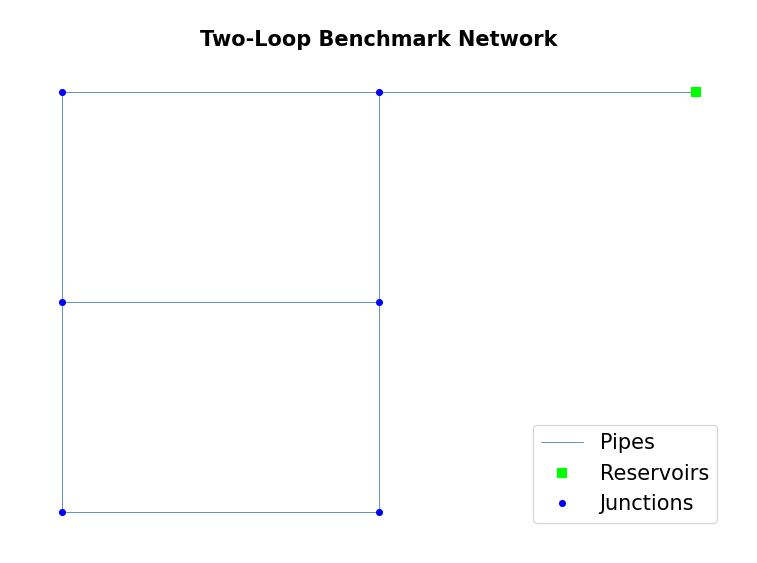

In [ ]:

# Download the Two-Loop network file from the workshop repository
!wget -q https://raw.githubusercontent.com/ChrisMichalopoulos/workshop_optimisation/refs/heads/main/Notebooks/networks/twoloop.inp

NETWORK_PATH = "twoloop.inp"
PRESSURE_GOAL = 30  # minimum acceptable pressure at every junction [m]

d = epanet(NETWORK_PATH)
print("Network loaded.")
print(f"  Junctions : {d.getNodeJunctionCount()}")
print(f"  Pipes     : {d.getLinkPipeCount()}")
d.plot(figure=True, title="Two-Loop Benchmark Network");

## 3. The Hydraulic Performance Model

### Decision Variables

A **decision vector** `x` is a list of 8 integers — one per pipe — where each integer is an index into the diameter table below. For example, `x = [3, 5, 3, 5, 5, 3, 4, 5]` assigns pipe 0 a 101.6 mm diameter, pipe 1 a 203.2 mm diameter, and so on.

| Index | Diameter (mm) | Nominal Size | Unit Cost (EUR/m) |
|------:|:-------------|:------------|------------------:|
| 0 | 25.4 | 1 inch | 2 |
| 1 | 50.8 | 2 inch | 5 |
| 2 | 76.2 | 3 inch | 8 |
| 3 | 101.6 | 4 inch | 11 |
| 4 | 152.4 | 6 inch | 16 |
| 5 | 203.2 | 8 inch | 23 |
| 6 | 254.0 | 10 inch | 32 |
| 7 | 304.8 | 12 inch | 50 |
| 8 | 355.6 | 14 inch | 60 |
| 9 | 406.4 | 16 inch | 90 |
| 10 | 457.2 | 18 inch | 130 |
| 11 | 508.0 | 20 inch | 170 |
| 12 | 558.8 | 22 inch | 300 |
| 13 | 609.6 | 24 inch | 550 |

### Objectives and Constraints

| | Description |
|-|-------------|
| **Objective** | Total network cost (EUR): `sum( cost_per_metre[i] * pipe_length[i] )` |
| **Constraint** | Pressure at all junctions >= 30 m: `deficit = sum( max(0, 30 - p) )` |

A solution is **feasible** when `pressure_deficit = 0`.


In [ ]:
class HydraulicPerformances:
    """Wraps the EPANET network and evaluates objectives for a given diameter assignment."""

    AVAILABLE_DIAMETERS = [
        25.4, 50.8, 76.2, 101.6, 152.4, 203.2, 254.0,
        304.8, 355.6, 406.4, 457.2, 508.0, 558.8, 609.6
    ]  # mm  (1" to 24" nominal pipe sizes)

    UNIT_COST = np.array([
        2.0, 5.0, 8.0, 11.0, 16.0, 23.0, 32.0,
        50.0, 60.0, 90.0, 130.0, 170.0, 300.0, 550.0
    ])  # EUR/m

    def __init__(self, inp_path: str):
        self.network = epanet(inp_path, display_msg=False, display_warnings=False)
        self.network.setDemandModel('PDA', 5, 20, 0.5)

        n_junctions = self.network.getNodeJunctionCount()
        self.source_indices = list(range(n_junctions, self.network.getNodeCount()))

        self.pipe_indices = self.network.getLinkIndex()
        self.pipe_lengths  = np.array(
            [self.network.getLinkLength(i) for i in self.pipe_indices]
        )

    def calculateObjectives(self, x: list) -> Tuple[float, float]:
        """Return (total_cost_eur, pressure_deficit_m) for decision vector x."""
        for pipe_id, diam_idx in zip(self.pipe_indices, x):
            self.network.setLinkDiameter(pipe_id, self.AVAILABLE_DIAMETERS[diam_idx])

        total_cost = float(np.sum(self.UNIT_COST[x] * self.pipe_lengths))

        pressures = self.network.getComputedHydraulicTimeSeries().Pressure
        junction_pressures = np.delete(pressures, self.source_indices, axis=1)
        pressure_deficit = float(
            np.maximum(PRESSURE_GOAL - junction_pressures[0, :], 0).sum()
        )
        return total_cost, pressure_deficit


hydraulic_model = HydraulicPerformances(NETWORK_PATH)
print("HydraulicPerformances model ready.")

HydraulicPerformances model ready.


###  Quick Sanity Check: Extreme Cases

Let's verify the model works by testing the two most extreme configurations:

- 🔻 **All smallest pipes** (`x = [0,...,0]`) — cheapest, but almost certainly insufficient pressure
- 🔺 **All largest pipes** (`x = [13,...,13]`) — very expensive, but definitely adequate pressure


This also establishes the <b>theoretical cost bounds</b> for our problem.


In [ ]:
x_small = [0] * 8
cost_s, deficit_s = hydraulic_model.calculateObjectives(x_small)
print(f'All pipes @ {HydraulicPerformances.AVAILABLE_DIAMETERS[0]:.1f} mm (index 0):')
print(f'  Cost             : {cost_s:>12,.2f} EUR')
print(f'  Pressure deficit : {deficit_s:.2f} m')

x_large = [13] * 8
cost_l, deficit_l = hydraulic_model.calculateObjectives(x_large)
print(f'\nAll pipes @ {HydraulicPerformances.AVAILABLE_DIAMETERS[13]:.1f} mm (index 13):')
print(f'  Cost             : {cost_l:>12,.2f} EUR')
print(f'  Pressure deficit : {deficit_l:.2f} m')

All pipes @ 25.4 mm (index 0):
  Cost             :    16,000.00 EUR
  Pressure deficit : 189.99 m

All pipes @ 609.6 mm (index 13):
  Cost             : 4,400,000.00 EUR
  Pressure deficit : 0.00 m


## 4. Why Brute Force Fails

With 8 pipes and 14 diameter choices each, the full search space has:

14⁸ = 1,475,789,056 combinations  (~1.5 billion) 🚫


Each evaluation requires a full EPANET hydraulic simulation. The cell below runs **1,000 samples** and extrapolates the total time needed for exhaustive search.

In [ ]:
n_pipes = len(hydraulic_model.pipe_indices)
all_combos = product(
    range(len(HydraulicPerformances.AVAILABLE_DIAMETERS)), repeat=n_pipes
)
N_SAMPLE = 1_000

best_cost = float('inf')
best_solution = None

print(f'Running {N_SAMPLE:,} sample simulations...')
t0 = time.time()

for combo in tqdm(islice(all_combos, N_SAMPLE), total=N_SAMPLE):
    cost, deficit = hydraulic_model.calculateObjectives(list(combo))
    if deficit < 0.01 and cost < best_cost:
        best_solution, best_cost = combo, cost

elapsed  = time.time() - t0
avg_ms   = elapsed / N_SAMPLE * 1000
total_h  = (elapsed / N_SAMPLE) * 14**8 / 3600

print(f'\n{N_SAMPLE:,} simulations in {elapsed:.1f} s  ({avg_ms:.1f} ms each)')
print(f'\nExtrapolation to all {14**8:,} combinations:')
print(f'  Estimated time : {total_h:,.0f} hours  ({total_h/24:,.0f} days  /  {total_h/24/365:.1f} years)')
if best_solution:
    print(f'\nBest feasible found in sample: {best_cost:,.2f} EUR')
else:
    print('\nNo feasible solution found in the sampled subset.')

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._boots

Running 1,000 sample simulations...


100%|██████████| 1000/1000 [00:02<00:00, 446.13it/s]


1,000 simulations in 2.3 s  (2.3 ms each)

Extrapolation to all 1,475,789,056 combinations:
  Estimated time : 925 hours  (39 days  /  0.1 years)

No feasible solution found in the sampled subset.


⏰ <b>Takeaway:</b> Even for this tiny 8-pipe network, exhaustive search would take more than 30 days.

## 5. Meta-heuristic Optimisation with PyGMO

Meta-heuristics are nature-inspired strategies that **intelligently explore** a search space without evaluating every candidate.

### How it works

```
1. Generate an initial POPULATION of random solutions
2. EVALUATE each solution (run the hydraulic simulation)
3. SELECT the best solutions
4. RECOMBINE / MUTATE them to produce new candidates
5. REPEAT until a stopping criterion is met
```

### Algorithm: Self-Adaptive Differential Evolution (SADE)

**Differential Evolution** evolves a population by combining existing solutions:

| Operator | Role |
|----------|------|
|✨ **Mutation** | Create a donor vector by adding the scaled difference of two random individuals to a third: `v = x_r1 + F · (x_r2 - x_r3)` |
|🔀 **Crossover** | Mix the donor vector with the target individual to produce a trial vector |
|🏆 **Selection** | Keep the trial vector only if it improves on the target (greedy one-to-one replacement) |

The **self-adaptive** variant automatically tunes the scale factor `F` and crossover rate `CR` during the run, removing the need to hand-pick them. PyGMO's `sade` utilizes the following parameters:

| Parameter | Meaning | Typical value |
|-----------|---------|:--------------|
| `gen` | Number of generations | 100–500 |
| `variant` | Mutation/crossover strategy (1–18, e.g. `rand/1/exp`, `best/1/bin`, `rand-to-best/1/exp`) | 2 |
| `variant_adptv` | Adaptation scheme for `F` and `CR`: `1` = jDE, `2` = iDE | 1 |
| `ftol` | Stopping tolerance on objective function | 1e-6 |
| `xtol` | Stopping tolerance on decision vector | 1e-6 |


## Constraint Handling: The Penalty Method

🆘 Most GA implementations — including PyGMO's `sade` — **do not support explicit constraints**. Instead, we fold the pressure constraint into the objective using a **penalty term**:

```python
if deficit > 0:
    # Fixed barrier of 1,000,000 plus a multiplier scaling with the deficit size
    penalty = 1e6 + (deficit * 10000)

penalised_cost = cost + penalty
```

This is a **two-part penalty**:

- **Fixed barrier (`1e6`)** — a large constant added the moment any deficit appears. It creates a sharp discontinuity between feasible and infeasible solutions, ensuring even a tiny constraint violation costs more than any realistic feasible design.
- **Linear term (`deficit × 10000`)** — scales with the size of the violation, giving the algorithm a useful gradient: a solution that *almost* satisfies the constraint is ranked better than one that violates it badly, so the search can climb its way back into the feasible region.

When a solution satisfies the pressure constraint (`deficit = 0`), the penalty vanishes and penalised cost equals true cost. When it violates the constraint, the cost is artificially inflated, pushing the algorithm away from infeasible regions.

**Choosing the penalty coefficients:** they must be large enough that *no infeasible solution is ever preferred over the worst feasible one*.

| 🔻 Penalty too small | ✅ Penalty just right | 🔺 Penalty too large |
|:-----------------:|:------------------:|:-----------------:|
| Infeasible solutions compete with feasible ones; constraint may never be met | Algorithm reliably finds feasible low-cost solutions | All search effort is spent reducing deficit; cost minimisation suffers |

### PyGMO User-Defined Problem (UDP)

To use PyGMO we implement a class with these required methods:

| Method | Returns | Description |
|--------|---------|-------------|
| `get_bounds()` | `(lb, ub)` | Lower and upper bounds per variable |
| `get_nix()` | `int` | Number of integer variables |
| `get_nobj()` | `int` | Number of objectives (`1` = single-objective) |
| `get_nic()` | `int` | Inequality constraints — **`0`** when using penalty method |
| `fitness(x)` | `[penalised_cost]` | Single penalised value returned |

In [ ]:
class PipeDiamDecider:
    """PyGMO UDP for pipe-diameter optimisation using a penalty method."""

    AVAILABLE_DIAMETERS = [
        25.4, 50.8, 76.2, 101.6, 152.4, 203.2, 254.0,
        304.8, 355.6, 406.4, 457.2, 508.0, 558.8, 609.6
    ]  # mm

    def __init__(self, network):
        network.setDemandModel('PDA', 15, 20, 0.5)

        self.pipe_indices = network.getLinkIndex()
        self.pipe_lengths = np.array(
            [network.getLinkLength(i) for i in self.pipe_indices]
        )

        n_pipes  = len(self.pipe_indices)
        self.lb = np.zeros(n_pipes, dtype=int)
        self.ub = np.full(n_pipes, len(self.AVAILABLE_DIAMETERS) - 1, dtype=int)

    # --- Required PyGMO interface ---

    def get_bounds(self) -> Tuple[np.ndarray, np.ndarray]:
        return self.lb, self.ub

    def get_nix(self) -> int:
        return len(self.lb)  # all variables are integer (diameter indices)

    def get_nobj(self) -> int:
        return 1  # single penalised objective

    def get_nic(self) -> int:
        return 0  # no explicit constraints — folded into objective via penalty

    def fitness(self, x: np.ndarray):
        cost, deficit = hydraulic_model.calculateObjectives(x.astype(int))

        penalty = 0.0
        if deficit > 0:
            # We add 1,000,000 plus a multiplier for the size of the deficit
            penalty = 1e6 + (deficit * 10_000)

        penalised_cost = cost + penalty
        return np.array([penalised_cost])


decider = PipeDiamDecider(hydraulic_model.network)
prob = pygmo.problem(decider)
print("UDP defined and wrapped in pygmo.problem.")
print(f"  Decision variables : {len(decider.lb)} (one index per pipe)")
print(f"  Variable bounds    : 0 to {int(decider.ub[0])}")
print(f"  Objectives         : {prob.get_nobj()} (penalised cost)")

UDP defined and wrapped in pygmo.problem.
  Decision variables : 8 (one index per pipe)
  Variable bounds    : 0 to 13
  Objectives         : 1 (penalised cost)


## 6. Run the Optimisation


Algorithm: <code>pygmo.sga</code> (Genetic Algorithm)    #TODO ADD
</div>

**Settings:**
- 👥 **Population size:** 200 individuals (198 random + 2 boundary seeds)
- 🔁 **Generations:** 50

Boundary seeding adds the all-minimum and all-maximum solutions so the algorithm sees the full range of the search space from the very first generation.


⏱️ This cell typically takes <b>~1 minute</b>.

In [ ]:
algo = pygmo.algorithm(pygmo.sade(
    gen=50
))

pop = pygmo.population(prob, size=198)
pop.push_back(decider.lb)   # seed: all smallest diameters
pop.push_back(decider.ub)   # seed: all largest diameters

print("Evolving population (50 generations, size 200)...")
pop = algo.evolve(pop)
print("Done.")

Evolving population (50 generations, size 200)...
Done.


### Performance Bounds (with Penalty)

Let's verify the penalty values for the extreme cases so we can confirm the penalty weight is calibrated correctly.

In [ ]:
d_min = HydraulicPerformances.AVAILABLE_DIAMETERS[0]
d_max = HydraulicPerformances.AVAILABLE_DIAMETERS[-1]

cost_small, def_small = hydraulic_model.calculateObjectives([0]*8)
cost_large, def_large = hydraulic_model.calculateObjectives([13]*8)

print(f'Worst case (all {d_min} mm):')
print(f'  True cost       : {cost_small:>12,.2f} EUR   deficit = {def_small:.2f} m')

print(f'\nBest case  (all {d_max} mm):')
print(f'  True cost       : {cost_large:>12,.2f} EUR   deficit = {def_large:.2f} m')

# Decode champion: re-evaluate to get true cost and deficit
champ_x = pop.champion_x.astype(int)
champ_cost, champ_def = hydraulic_model.calculateObjectives(champ_x)
print(f'\nOptimised champion:')
print(f'  True cost       : {champ_cost:>12,.2f} EUR   deficit = {champ_def:.2f} m')
print(f'  Penalised cost  : {pop.champion_f[0]:>12,.2f} EUR')

Worst case (all 25.4 mm):
  True cost       :    16,000.00 EUR   deficit = 130.00 m

Best case  (all 609.6 mm):
  True cost       : 4,400,000.00 EUR   deficit = 0.00 m

Optimised champion:
  True cost       :   424,000.00 EUR   deficit = 0.00 m
  Penalised cost  :   424,000.00 EUR


### The Champion Solution

🏆 The **champion** is the individual with the lowest *penalised* cost. We re-evaluate it to recover the true cost and check feasibility.

In [ ]:
best_x = pop.champion_x.astype(int)
best_diameters = [decider.AVAILABLE_DIAMETERS[i] for i in best_x]

# Re-evaluate to get true (unpenalised) cost and deficit
best_cost, best_deficit = hydraulic_model.calculateObjectives(best_x)

print("=" * 52)
print("OPTIMISED SOLUTION")
print("=" * 52)
print(f'Diameter indices  : {[int(i) for i in best_x]}')
print(f'Diameters (mm)    : {best_diameters}')
print(f'True cost         : {best_cost:>12,.2f} EUR')
print(f'Pressure deficit  : {best_deficit:.4f} m')
feasibility = 'FEASIBLE' if best_deficit < 0.01 else f'INFEASIBLE — deficit: {best_deficit:.2f} m'
print(f'Result            : {feasibility}')
print(f'\nPenalised fitness : {pop.champion_f[0]:>12,.2f} EUR')

OPTIMISED SOLUTION
Diameter indices  : [10, 8, 8, 0, 8, 0, 8, 7]
Diameters (mm)    : [457.2, 355.6, 355.6, 25.4, 355.6, 25.4, 355.6, 304.8]
True cost         :   424,000.00 EUR
Pressure deficit  : 0.0000 m
Result            : FEASIBLE

Penalised fitness :   424,000.00 EUR


## 7. Convergence Analysis

Because meta-heuristics are **stochastic**, results vary between runs. A convergence plot shows how the best fitness improves with each generation.

With the penalty method, the plotted value is the **penalised cost**. Once the champion solution becomes feasible (deficit = 0), penalised cost equals true cost — you will see the curve settle to a value much lower than the early penalty-inflated values.

Reading the plot:
- **Very high early values** — champion is infeasible; penalty dominates
- **Sharp drop** — algorithm finds first feasible solution
- **Slow improvement after drop** — refining within the feasible region
- **Flat plateau** — converged; more generations give diminishing returns

We re-run with `gen=1` inside a manual loop to capture progress at every generation.

> **Discussion:** How many generations does it take to first find a feasible solution? Does the true cost keep improving after that?

Tracking convergence over 100 generations...

  Gen  10: penalised =   514,000.00 EUR  (FEASIBLE, cost=514,000 EUR)
  Gen  20: penalised =   474,000.00 EUR  (FEASIBLE, cost=474,000 EUR)
  Gen  30: penalised =   473,000.00 EUR  (FEASIBLE, cost=473,000 EUR)
  Gen  40: penalised =   437,000.00 EUR  (FEASIBLE, cost=437,000 EUR)
  Gen  50: penalised =   437,000.00 EUR  (FEASIBLE, cost=437,000 EUR)
  Gen  60: penalised =   431,000.00 EUR  (FEASIBLE, cost=431,000 EUR)
  Gen  70: penalised =   426,000.00 EUR  (FEASIBLE, cost=426,000 EUR)
  Gen  80: penalised =   426,000.00 EUR  (FEASIBLE, cost=426,000 EUR)
  Gen  90: penalised =   423,000.00 EUR  (FEASIBLE, cost=423,000 EUR)
  Gen 100: penalised =   423,000.00 EUR  (FEASIBLE, cost=423,000 EUR)

Final solution:
  Diameters : [508.0, 254.0, 406.4, 25.4, 355.6, 254.0, 254.0, 50.8] mm
  True cost :   423,000.00 EUR
  Deficit   : 0.0000 m
  First feasible at generation: 1


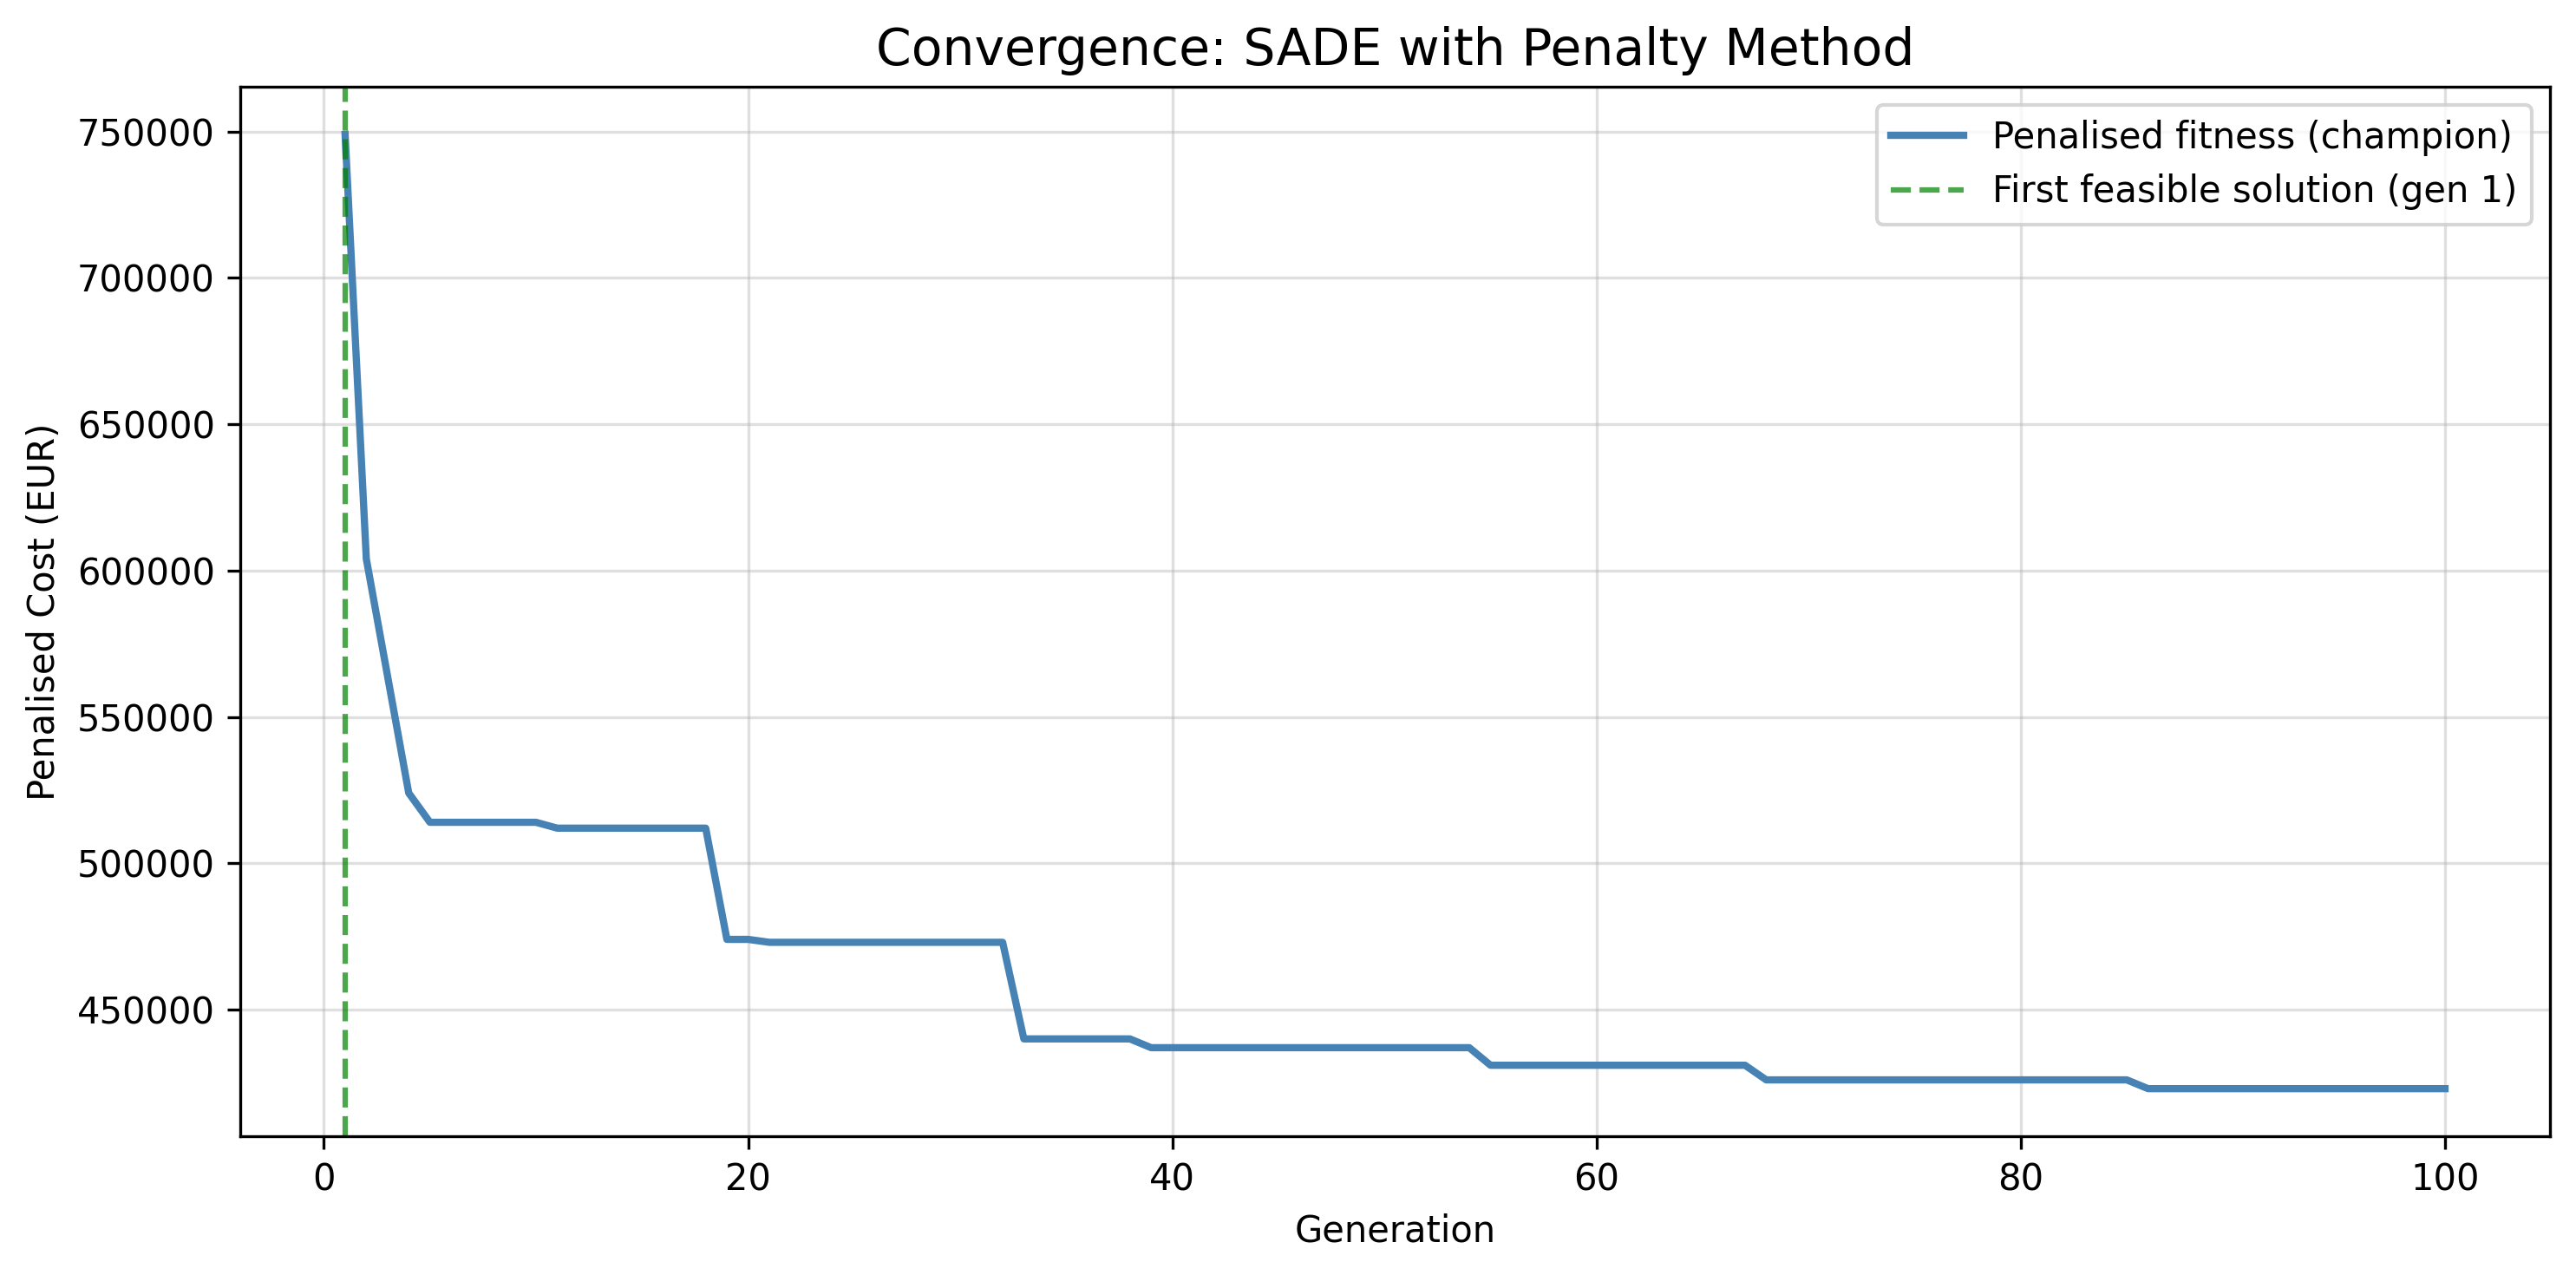

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


In [ ]:
N_GENERATIONS = 100
POP_SIZE = 198

decider2 = PipeDiamDecider(hydraulic_model.network)
prob2 = pygmo.problem(decider2)

algo_step = pygmo.algorithm(pygmo.sade(
    gen=1
))
pop2 = pygmo.population(prob2, size=POP_SIZE)
pop2.push_back(decider2.lb)
pop2.push_back(decider2.ub)

penalised_history = []
first_feasible_gen = None

print(f"Tracking convergence over {N_GENERATIONS} generations...\n")

for g in range(N_GENERATIONS):
    pop2 = algo_step.evolve(pop2)
    penalised_history.append(pop2.champion_f[0])

    champ_x2 = pop2.champion_x.astype(int)
    raw_cost2, raw_def2 = hydraulic_model.calculateObjectives(champ_x2)
    if raw_def2 < 0.01 and first_feasible_gen is None:
        first_feasible_gen = g + 1

    if (g + 1) % 10 == 0:
        status = f'FEASIBLE, cost={raw_cost2:,.0f} EUR' if raw_def2 < 0.01 else f'infeasible, deficit={raw_def2:.1f} m'
        print(f'  Gen {g+1:3d}: penalised = {pop2.champion_f[0]:>12,.2f} EUR  ({status})')

final_x2 = pop2.champion_x.astype(int)
final_cost2, final_def2 = hydraulic_model.calculateObjectives(final_x2)
print("\nFinal solution:")
print(f'  Diameters : {[decider2.AVAILABLE_DIAMETERS[i] for i in final_x2]} mm')
print(f'  True cost : {final_cost2:>12,.2f} EUR')
print(f'  Deficit   : {final_def2:.4f} m')
if first_feasible_gen:
    print(f'  First feasible at generation: {first_feasible_gen}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, N_GENERATIONS + 1), penalised_history, color='steelblue', linewidth=2,
        label='Penalised fitness (champion)')
if first_feasible_gen:
    ax.axvline(x=first_feasible_gen, color='green', linestyle='--', alpha=0.7,
               label=f'First feasible solution (gen {first_feasible_gen})')
ax.set_title('Convergence: SADE with Penalty Method', fontsize=14)
ax.set_xlabel('Generation')
ax.set_ylabel('Penalised Cost (EUR)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Key Takeaways

| Concept | What we learned |
|---------|----------------|
| **Combinatorial explosion** | 8 pipes, 14 choices each = 1.5 billion configs; brute force takes thousands of years |
| **Simulation-based evaluation** | Each fitness call runs a full hydraulic simulation — no fast surrogate |
| **Penalty method** | Fold constraints into the objective: `penalised = cost + (1e6 + 10000 x deficit)` when infeasible |
| **Two-part penalty design** | Fixed barrier (`1e6`) cleanly separates feasible from infeasible; linear term (`10000 x deficit`) gives a gradient guiding the search back to feasibility |

---